In [14]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # fix — was overwritten by seaborn
import seaborn as sns             # fix — use sns not plt
import warnings
warnings.filterwarnings('ignore')

!pip install PyPortfolioOpt -q

from pypfopt import EfficientFrontier, risk_models, expected_returns
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices

# Load data
data       = pd.read_csv('/content/drive/MyDrive/nifty50_processed_data.csv')
signals_df = pd.read_csv('/content/drive/MyDrive/nifty50_signals.csv')
results_df = pd.read_csv('/content/drive/MyDrive/nifty50_model_results.csv')

data['Date'] = pd.to_datetime(data['Date'])
data.sort_values(['Symbol','Date'], inplace=True)
data.reset_index(drop=True, inplace=True)

print("Data loaded ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded ✅


In [2]:
# Pivot to get closing prices: rows=Date, cols=Symbol
price_matrix = data.pivot_table(index='Date', columns='Symbol', values='Close')

# Keep only stocks with enough data (at least 80% filled)
price_matrix = price_matrix.dropna(thresh=int(0.8 * len(price_matrix)), axis=1)
price_matrix = price_matrix.fillna(method='ffill').fillna(method='bfill')

print(f"Price matrix shape : {price_matrix.shape}")
print(f"Stocks available   : {price_matrix.shape[1]}")
print(f"Date range         : {price_matrix.index.min()} to {price_matrix.index.max()}")

Price matrix shape : (5306, 37)
Stocks available   : 37
Date range         : 2000-01-03 00:00:00 to 2021-04-30 00:00:00


In [3]:
sector_map = {
    'ADANIPORTS': 'Infrastructure', 'ASIANPAINT': 'Consumer Goods',
    'AXISBANK': 'Banking', 'BAJAJ-AUTO': 'Automobile',
    'BAJAJFINSV': 'Financial Services', 'BAJFINANCE': 'Financial Services',
    'BHARTIARTL': 'Telecom', 'BPCL': 'Energy',
    'BRITANNIA': 'Consumer Goods', 'CIPLA': 'Pharma',
    'COALINDIA': 'Energy', 'DRREDDY': 'Pharma',
    'EICHERMOT': 'Automobile', 'GAIL': 'Energy',
    'GRASIM': 'Cement', 'HCLTECH': 'IT',
    'HDFC': 'Financial Services', 'HDFCBANK': 'Banking',
    'HDFCLIFE': 'Insurance', 'HEROMOTOCO': 'Automobile',
    'HINDALCO': 'Metals', 'HINDUNILVR': 'Consumer Goods',
    'ICICIBANK': 'Banking', 'INDUSINDBK': 'Banking',
    'INFY': 'IT', 'IOC': 'Energy',
    'ITC': 'Consumer Goods', 'JSWSTEEL': 'Metals',
    'KOTAKBANK': 'Banking', 'LT': 'Infrastructure',
    'M&M': 'Automobile', 'MARUTI': 'Automobile',
    'NESTLEIND': 'Consumer Goods', 'NTPC': 'Energy',
    'ONGC': 'Energy', 'POWERGRID': 'Energy',
    'RELIANCE': 'Energy', 'SBILIFE': 'Insurance',
    'SBIN': 'Banking', 'SHREECEM': 'Cement',
    'SUNPHARMA': 'Pharma', 'TATACONSUM': 'Consumer Goods',
    'TATAMOTORS': 'Automobile', 'TATASTEEL': 'Metals',
    'TCS': 'IT', 'TECHM': 'IT',
    'TITAN': 'Consumer Goods', 'ULTRACEMCO': 'Cement',
    'UPL': 'Chemicals', 'WIPRO': 'IT',
    'ZEEL': 'Media'
}

# Stable sectors for conservative, growth for aggressive
conservative_sectors = ['Consumer Goods', 'Pharma', 'IT', 'Banking', 'Insurance']
aggressive_sectors   = ['Automobile', 'Metals', 'Energy', 'Infrastructure', 'Chemicals', 'Telecom']
balanced_sectors     = list(set(conservative_sectors + aggressive_sectors))

def get_stocks_by_sector(sectors):
    return [s for s, sec in sector_map.items()
            if sec in sectors and s in price_matrix.columns]

conservative_stocks = get_stocks_by_sector(conservative_sectors)
aggressive_stocks   = get_stocks_by_sector(aggressive_sectors)
balanced_stocks     = list(price_matrix.columns)  # all stocks

print(f"Conservative stocks : {len(conservative_stocks)} → {conservative_stocks}")
print(f"Aggressive stocks   : {len(aggressive_stocks)}   → {aggressive_stocks}")
print(f"Balanced stocks     : {len(balanced_stocks)}")

Conservative stocks : 17 → ['ASIANPAINT', 'AXISBANK', 'BRITANNIA', 'CIPLA', 'DRREDDY', 'HCLTECH', 'HDFCBANK', 'HINDUNILVR', 'ICICIBANK', 'INDUSINDBK', 'INFY', 'ITC', 'KOTAKBANK', 'SBIN', 'SUNPHARMA', 'TITAN', 'WIPRO']
Aggressive stocks   : 13   → ['BHARTIARTL', 'BPCL', 'EICHERMOT', 'GAIL', 'HEROMOTOCO', 'HINDALCO', 'IOC', 'MARUTI', 'ONGC', 'RELIANCE', 'TATAMOTORS', 'TATASTEEL', 'UPL']
Balanced stocks     : 37


In [4]:
def optimize_portfolio(price_data, profile='balanced', top_n=10):
    """
    Optimizes portfolio using Mean-Variance Optimization.
    - Conservative : Minimum Volatility
    - Balanced     : Maximum Sharpe Ratio
    - Aggressive   : Maximum Return
    """
    # Calculate expected returns and covariance matrix
    mu  = expected_returns.mean_historical_return(price_data)
    cov = risk_models.sample_cov(price_data)

    ef = EfficientFrontier(mu, cov)

    if profile == 'conservative':
        ef.min_volatility()
    elif profile == 'balanced':
        ef.max_sharpe(risk_free_rate=0.06)   # 6% risk free rate (India)
    elif profile == 'aggressive':
        ef.efficient_return(target_return=0.25)  # target 25% annual return

    weights = ef.clean_weights()
    perf    = ef.portfolio_performance(verbose=False, risk_free_rate=0.06)

    # Convert to dataframe
    weights_df = pd.DataFrame(list(weights.items()),
                               columns=['Symbol', 'Weight'])
    weights_df = weights_df[weights_df['Weight'] > 0.001]
    weights_df = weights_df.sort_values('Weight', ascending=False)
    weights_df['Sector'] = weights_df['Symbol'].map(sector_map)
    weights_df['Weight_Pct'] = (weights_df['Weight'] * 100).round(2)

    return weights_df, perf

In [6]:
price_conservative = price_matrix[conservative_stocks]

w_con, perf_con = optimize_portfolio(price_conservative, profile='conservative')

print("=" * 50)
print("🟢 CONSERVATIVE PORTFOLIO")
print("=" * 50)
print(f"Expected Annual Return : {perf_con[0]*100:.2f}%")
print(f"Annual Volatility      : {perf_con[1]*100:.2f}%")
print(f"Sharpe Ratio           : {perf_con[2]:.4f}")
print("\nStock Allocations:")
print(w_con[['Symbol','Sector','Weight_Pct']].to_string(index=False))

    Symbol         Sector  Weight_Pct
 BRITANNIA Consumer Goods       19.66
ASIANPAINT Consumer Goods       16.08
HINDUNILVR Consumer Goods       10.65
   DRREDDY         Pharma       10.48
       ITC Consumer Goods        9.46
     CIPLA         Pharma        8.10
  HDFCBANK        Banking        8.05
 SUNPHARMA         Pharma        5.43
      INFY             IT        4.87
      SBIN        Banking        2.36
 KOTAKBANK        Banking        1.79
     TITAN Consumer Goods        1.51
     WIPRO             IT        0.95
   HCLTECH             IT        0.62


In [7]:
w_bal, perf_bal = optimize_portfolio(price_matrix, profile='balanced')

print("=" * 50)
print("🟡 BALANCED PORTFOLIO")
print("=" * 50)
print(f"Expected Annual Return : {perf_bal[0]*100:.2f}%")
print(f"Annual Volatility      : {perf_bal[1]*100:.2f}%")
print(f"Sharpe Ratio           : {perf_bal[2]:.4f}")
print("\nStock Allocations:")
print(w_bal[['Symbol','Sector','Weight_Pct']].to_string(index=False))

🟡 BALANCED PORTFOLIO
Expected Annual Return : 28.52%
Annual Volatility      : 28.40%
Sharpe Ratio           : 0.7930

Stock Allocations:
    Symbol             Sector  Weight_Pct
  SHREECEM             Cement       58.71
    MARUTI         Automobile       18.34
BAJFINANCE Financial Services       16.54
 EICHERMOT         Automobile        6.42


In [10]:
from pypfopt import EfficientFrontier, risk_models, expected_returns

price_aggressive = price_matrix[aggressive_stocks]

mu_agg  = expected_returns.mean_historical_return(price_aggressive)
cov_agg = risk_models.sample_cov(price_aggressive)

# Find maximum achievable return first
ef_temp     = EfficientFrontier(mu_agg, cov_agg)
max_return  = ef_temp._max_return()

# Use 90% of max return as target
target = max_return * 0.90
print(f"Max possible return : {max_return*100:.2f}%")
print(f"Target return set to: {target*100:.2f}%")

# Now optimize
ef_agg = EfficientFrontier(mu_agg, cov_agg)
ef_agg.efficient_return(target_return=target)

weights  = ef_agg.clean_weights()
perf_agg = ef_agg.portfolio_performance(verbose=False, risk_free_rate=0.06)

# Build weights dataframe
w_agg = pd.DataFrame(list(weights.items()), columns=['Symbol', 'Weight'])
w_agg = w_agg[w_agg['Weight'] > 0.001].sort_values('Weight', ascending=False)
w_agg['Sector']     = w_agg['Symbol'].map(sector_map)
w_agg['Weight_Pct'] = (w_agg['Weight'] * 100).round(2)

print("=" * 50)
print("🔴 AGGRESSIVE PORTFOLIO")
print("=" * 50)
print(f"Expected Annual Return : {perf_agg[0]*100:.2f}%")
print(f"Annual Volatility      : {perf_agg[1]*100:.2f}%")
print(f"Sharpe Ratio           : {perf_agg[2]:.4f}")
print("\nStock Allocations:")
print(w_agg[['Symbol','Sector','Weight_Pct']].to_string(index=False))

Max possible return : 20.37%
Target return set to: 18.34%
🔴 AGGRESSIVE PORTFOLIO
Expected Annual Return : 18.34%
Annual Volatility      : 26.80%
Sharpe Ratio           : 0.4602

Stock Allocations:
    Symbol     Sector  Weight_Pct
    MARUTI Automobile       61.60
 EICHERMOT Automobile       22.71
BHARTIARTL    Telecom       15.68


       Profile Expected Return Volatility Sharpe Ratio
🟢 Conservative           3.26%     18.56%      -0.1476
    🟡 Balanced          28.52%     28.40%       0.7930
  🔴 Aggressive          18.34%     26.80%       0.4602


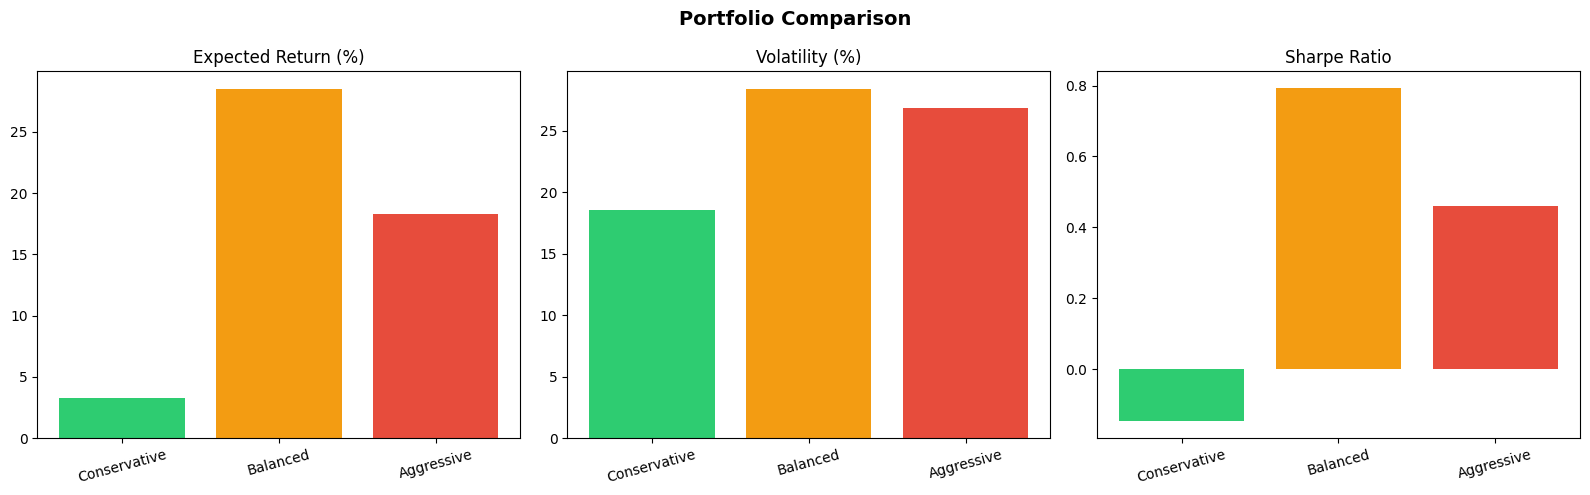

In [15]:
comparison = pd.DataFrame({
    'Profile'         : ['🟢 Conservative', '🟡 Balanced', '🔴 Aggressive'],
    'Expected Return' : [f"{perf_con[0]*100:.2f}%", f"{perf_bal[0]*100:.2f}%", f"{perf_agg[0]*100:.2f}%"],
    'Volatility'      : [f"{perf_con[1]*100:.2f}%", f"{perf_bal[1]*100:.2f}%", f"{perf_agg[1]*100:.2f}%"],
    'Sharpe Ratio'    : [f"{perf_con[2]:.4f}",      f"{perf_bal[2]:.4f}",      f"{perf_agg[2]:.4f}"]
})
print(comparison.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics  = ['Expected Return (%)', 'Volatility (%)', 'Sharpe Ratio']
con_vals = [perf_con[0]*100, perf_con[1]*100, perf_con[2]]
bal_vals = [perf_bal[0]*100, perf_bal[1]*100, perf_bal[2]]
agg_vals = [perf_agg[0]*100, perf_agg[1]*100, perf_agg[2]]

for i, (metric, cv, bv, av) in enumerate(zip(metrics, con_vals, bal_vals, agg_vals)):
    axes[i].bar(['Conservative', 'Balanced', 'Aggressive'],
                [cv, bv, av],
                color=['#2ecc71', '#f39c12', '#e74c3c'])
    axes[i].set_title(metric, fontsize=12)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Portfolio Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

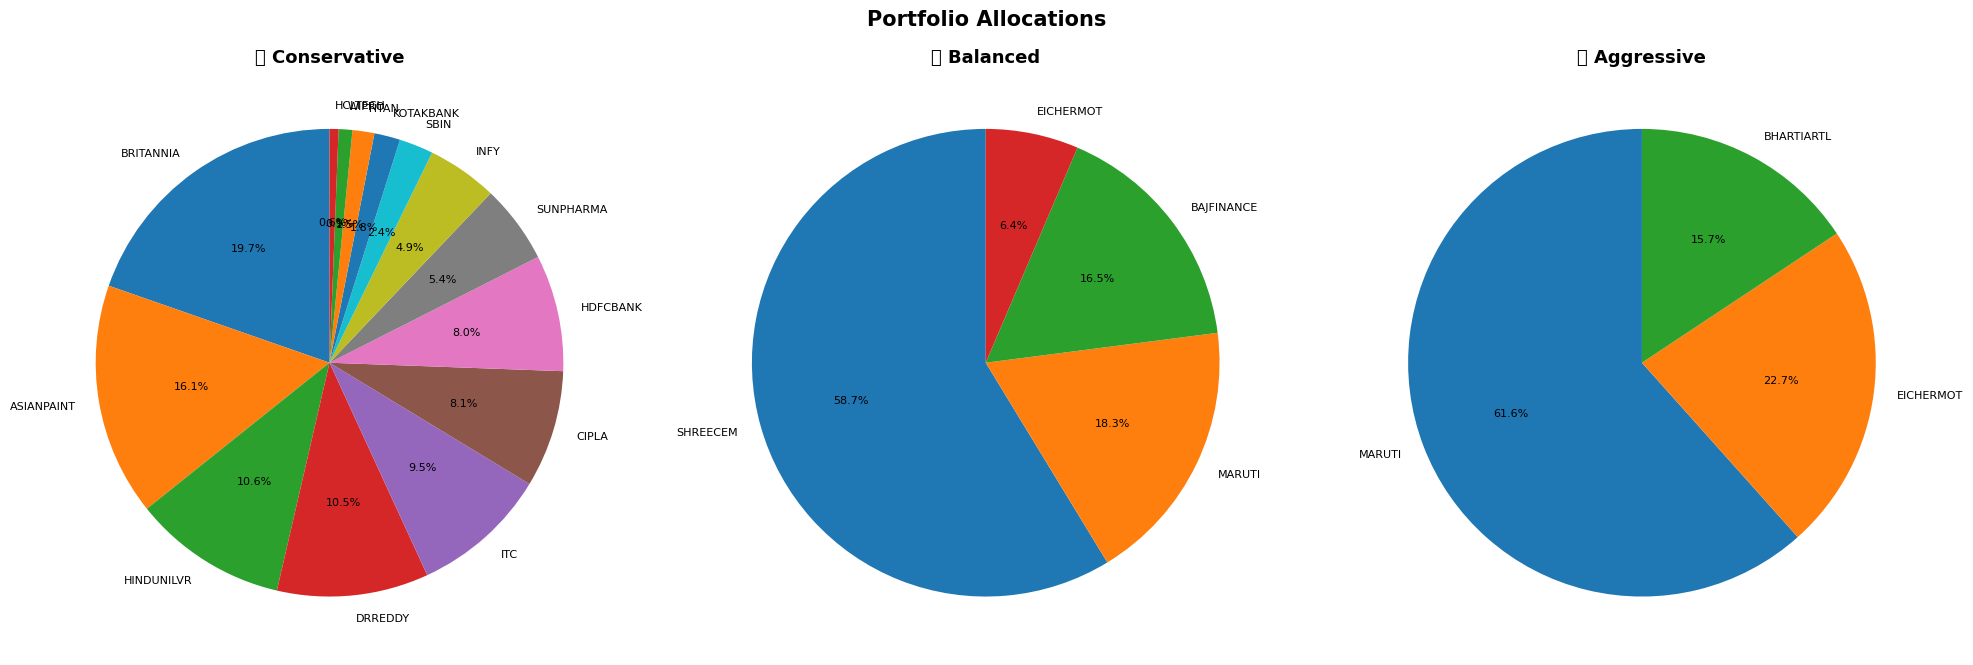

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, weights_df, title, color in zip(
    axes,
    [w_con, w_bal, w_agg],
    ['🟢 Conservative', '🟡 Balanced', '🔴 Aggressive'],
    ['Greens', 'Oranges', 'Reds']
):
    ax.pie(
        weights_df['Weight_Pct'],
        labels=weights_df['Symbol'],
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 8}
    )
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Portfolio Allocations', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

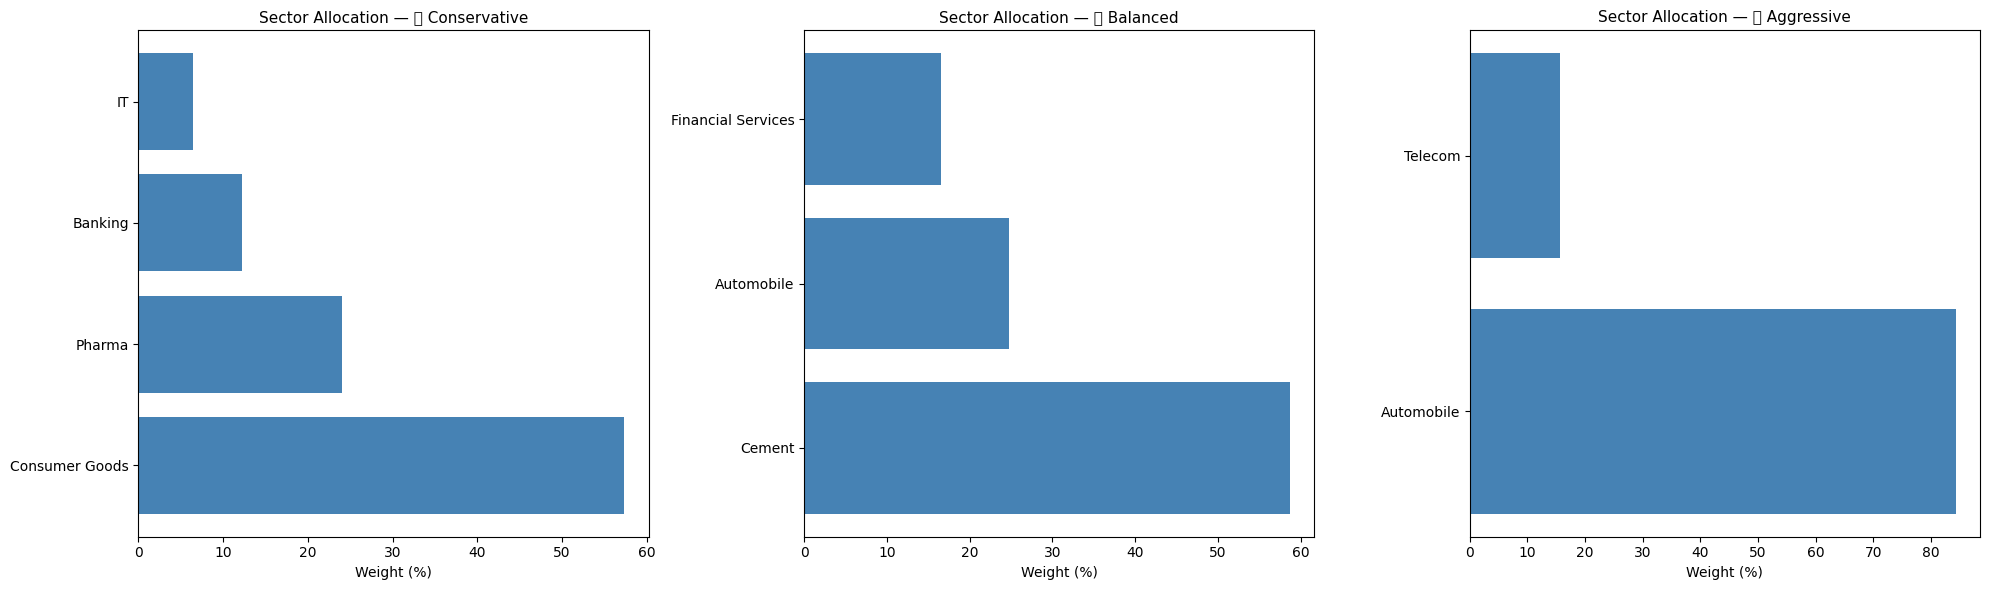

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, weights_df, title in zip(
    axes,
    [w_con, w_bal, w_agg],
    ['🟢 Conservative', '🟡 Balanced', '🔴 Aggressive']
):
    sector_wts = weights_df.groupby('Sector')['Weight_Pct'].sum().sort_values(ascending=False)
    ax.barh(sector_wts.index, sector_wts.values, color='steelblue')
    ax.set_title(f'Sector Allocation — {title}', fontsize=11)
    ax.set_xlabel('Weight (%)')

plt.tight_layout()
plt.show()

In [18]:
# Add profile column and combine
w_con['Profile'] = 'Conservative'
w_bal['Profile'] = 'Balanced'
w_agg['Profile'] = 'Aggressive'

all_portfolios = pd.concat([w_con, w_bal, w_agg], ignore_index=True)
all_portfolios.to_csv('/content/drive/MyDrive/nifty50_portfolios.csv', index=False)

# Save performance summary
perf_summary = pd.DataFrame({
    'Profile'          : ['Conservative', 'Balanced', 'Aggressive'],
    'Expected_Return'  : [perf_con[0], perf_bal[0], perf_agg[0]],
    'Volatility'       : [perf_con[1], perf_bal[1], perf_agg[1]],
    'Sharpe_Ratio'     : [perf_con[2], perf_bal[2], perf_agg[2]]
})
perf_summary.to_csv('/content/drive/MyDrive/nifty50_portfolio_performance.csv', index=False)

print("Portfolios saved to Drive ✅")
print(all_portfolios[['Profile','Symbol','Sector','Weight_Pct']].to_string(index=False))

Portfolios saved to Drive ✅
     Profile     Symbol             Sector  Weight_Pct
Conservative  BRITANNIA     Consumer Goods       19.66
Conservative ASIANPAINT     Consumer Goods       16.08
Conservative HINDUNILVR     Consumer Goods       10.65
Conservative    DRREDDY             Pharma       10.48
Conservative        ITC     Consumer Goods        9.46
Conservative      CIPLA             Pharma        8.10
Conservative   HDFCBANK            Banking        8.05
Conservative  SUNPHARMA             Pharma        5.43
Conservative       INFY                 IT        4.87
Conservative       SBIN            Banking        2.36
Conservative  KOTAKBANK            Banking        1.79
Conservative      TITAN     Consumer Goods        1.51
Conservative      WIPRO                 IT        0.95
Conservative    HCLTECH                 IT        0.62
    Balanced   SHREECEM             Cement       58.71
    Balanced     MARUTI         Automobile       18.34
    Balanced BAJFINANCE Financial Ser